In [22]:
#ROC curve for logistic regression
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [23]:
# Read the CSV file
df = pd.read_csv('loanacceptance.csv')
#df = pd.read_csv('multicommodity.csv')

print(df.head())

   Customer ID  Marital Status  Kids  Annual Household Salary  Loan Amount  \
0            1               0     0                   106020       185913   
1            2               0     2                  1270279      4907598   
2            3               1     3                  1086365      3012855   
3            4               1     2                   516564      2493950   
4            5               0     2                  1291768      4870552   

   Car owner  Education Level  Loan Granted  
0          1                0             0  
1          1                0             0  
2          1                0             1  
3          1                0             0  
4          1                5             1  


Setup the Data

In [24]:
X = df.drop('Loan Granted', axis=1)  # Features
y = df['Loan Granted']  # Target variable

Spliting the data and Training the model

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [26]:
#Now we are creating objects for classifier and training the classifier 
#with the train split of the dataset i.e x_train and y_train.

clf_reg = LogisticRegression();



In [27]:

clf_reg.fit(X_train, y_train);

c:\Users\abhin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [28]:
#Prediction by the trained models on the test data

y_score = clf_reg.predict(X_test)
y_p = clf_reg.predict_proba(X_test)
y_p

array([[0.03402422, 0.96597578],
       [0.35768286, 0.64231714],
       [0.0872655 , 0.9127345 ],
       [0.29960407, 0.70039593],
       [0.11451829, 0.88548171],
       [0.00591359, 0.99408641],
       [0.23758026, 0.76241974],
       [0.91143418, 0.08856582],
       [0.02075619, 0.97924381],
       [0.0382184 , 0.9617816 ],
       [0.5540033 , 0.4459967 ],
       [0.07747736, 0.92252264],
       [0.28722802, 0.71277198],
       [0.74646289, 0.25353711],
       [0.20545164, 0.79454836],
       [0.01097404, 0.98902596],
       [0.06501837, 0.93498163],
       [0.0389756 , 0.9610244 ],
       [0.13824963, 0.86175037],
       [0.27038336, 0.72961664],
       [0.0240396 , 0.9759604 ],
       [0.30003299, 0.69996701],
       [0.66820228, 0.33179772],
       [0.01025279, 0.98974721],
       [0.01391191, 0.98608809],
       [0.06994955, 0.93005045],
       [0.0251391 , 0.9748609 ],
       [0.05137567, 0.94862433],
       [0.17002742, 0.82997258],
       [0.00928134, 0.99071866],
       [0.

In [29]:
#keep probabilities for the positive outcome only
y_p = y_p[:,1]
print(y_p)

[0.96597578 0.64231714 0.9127345  0.70039593 0.88548171 0.99408641
 0.76241974 0.08856582 0.97924381 0.9617816  0.4459967  0.92252264
 0.71277198 0.25353711 0.79454836 0.98902596 0.93498163 0.9610244
 0.86175037 0.72961664 0.9759604  0.69996701 0.33179772 0.98974721
 0.98608809 0.93005045 0.9748609  0.94862433 0.82997258 0.99071866
 0.23862622 0.67065435 0.29608122 0.11966856 0.95110522 0.98942567
 0.59487737 0.94465494 0.9967421  0.35173681 0.83039019 0.65948917
 0.91744017 0.66894004 0.94999063 0.44799359 0.43022235 0.91488237
 0.99047807 0.41534535 0.99648806 0.40864483 0.94417864 0.9787238
 0.9341237  0.96628655 0.89695731 0.81398426 0.93274644 0.82131295
 0.45456073 0.99757863 0.48882783 0.42540204 0.59282322 0.9890314
 0.22578517 0.95978881 0.42415343 0.92235808 0.64549096 0.97581847
 0.98782864 0.96883483 0.9884326  0.42341493 0.66057477 0.86655557
 0.68839151 0.97110257 0.89994635 0.55981572 0.4776746  0.91211343
 0.59603353 0.95604514 0.99182358 0.58394029 0.92053719 0.9850429

In [30]:
#calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_p)
print(thresholds)

[       inf 0.99757863 0.96628655 0.96597578 0.93274644 0.92252264
 0.9127345  0.91211343 0.89640182 0.88693311 0.76241974 0.72961664
 0.68839151 0.67065435 0.64549096 0.59282322 0.58394029 0.54626443
 0.4776746  0.43022235 0.42540204 0.08856582]


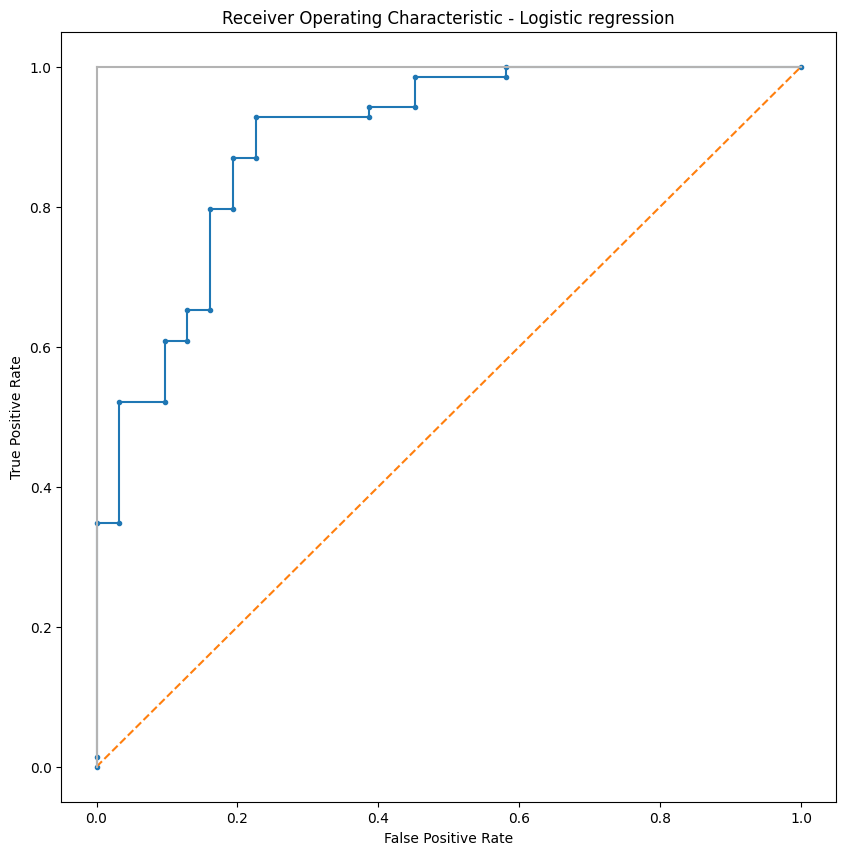

In [31]:
#Plot the roc curve for the model

plt.subplots(1, figsize=(10,10))
plt.title('Receiver Operating Characteristic - Logistic regression')
plt.plot(fpr, tpr, marker = '.', label = 'Logistic')
plt.plot([0, 1], ls="--")
plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [32]:
#get the best threshold 
J = tpr-fpr
ix = np.argmax(J)
best_thresh = thresholds[ix]
bfpr = fpr[ix]
btpr = tpr[ix]
print('Best Threshold = %f'%(best_thresh))

Best Threshold = 0.645491


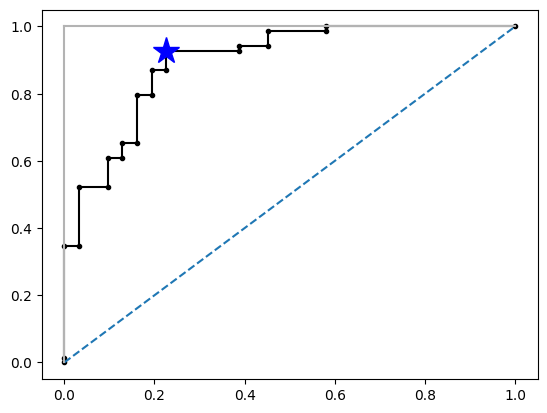

In [33]:
plt.plot(fpr, tpr, marker = '.', color = 'black',label = 'Logistic')
plt.plot([0, 1], ls="--")
plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7")
plt.plot(bfpr, btpr, marker = '*', color = 'blue', markersize=20)

In [34]:
roc_auc = roc_auc_score(y_test, y_p)
print('AUC: %.3f' % roc_auc)

AUC: 0.896


In [35]:
accuracy = clf_reg.score(X_test, y_test)
print('Accuracy: %.3f' % accuracy)

Accuracy: 0.830


In [36]:
F1_score = classification_report(y_test, y_score)
print(F1_score)

              precision    recall  f1-score   support

           0       0.85      0.55      0.67        31
           1       0.82      0.96      0.89        69

    accuracy                           0.83       100
   macro avg       0.84      0.75      0.78       100
weighted avg       0.83      0.83      0.82       100



In [37]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Train the Naive Bayes model
nb_clf = GaussianNB()   
nb_clf.fit(X_train, y_train)

# Predictions and positive-class probabilities
nb_y_score = nb_clf.predict(X_test)
nb_y_proba = nb_clf.predict_proba(X_test)[:, 1]

# Evaluation metrics
nb_accuracy = accuracy_score(y_test, nb_y_score)
nb_f1 = f1_score(y_test, nb_y_score)
nb_auc = roc_auc_score(y_test, nb_y_proba)

print(f"Naive Bayes Accuracy: {nb_accuracy:.3f}")
print(f"Naive Bayes F1 Score: {nb_f1:.3f}")
print(f"Naive Bayes AUC: {nb_auc:.3f}")

Naive Bayes Accuracy: 0.640
Naive Bayes F1 Score: 0.760
Naive Bayes AUC: 0.626
